In [2]:
!pip install yfinance --quiet

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")  # 그래프 예쁘게


In [6]:
# S&P500 (^GSPC), USD/KRW (KRW=X) 데이터 다운로드
sp500 = yf.download("^GSPC", start="2020-01-01")
fx = yf.download("KRW=X", start="2020-01-01")

# 각 종가(Close) 시리즈만 뽑기
sp500_close = sp500["Close"].copy()
fx_close = fx["Close"].copy()

# 시리즈 이름 붙이기
sp500_close.name = "SP500"
fx_close.name = "USDKRW"

# 날짜 기준으로 옆으로 붙이기
data = pd.concat([sp500_close, fx_close], axis=1).dropna()

data.head()


/tmp/ipython-input-3819565160.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3819565160.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fx = yf.download("KRW=X", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC,KRW=X
Date,,
2020-01-02,3257.850098,1153.969971
2020-01-03,3234.850098,1157.150024
2020-01-06,3246.280029,1165.849976
2020-01-07,3237.179932,1167.420044
2020-01-08,3253.050049,1166.459961


Columns: Index(['^GSPC', 'KRW=X'], dtype='object', name='Ticker')


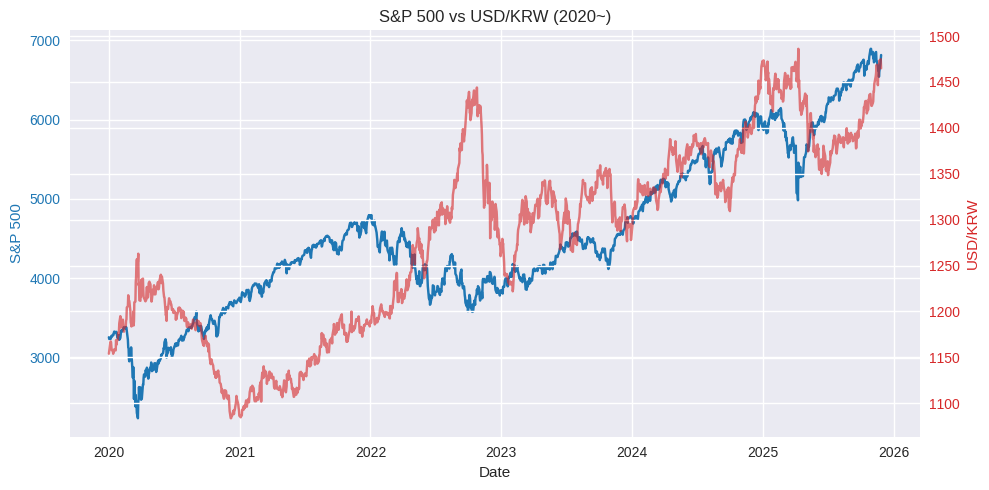

In [8]:
# 혹시 모를 디버깅용: 컬럼 이름 확인
print("Columns:", data.columns)

fig, ax1 = plt.subplots(figsize=(10,5))

# 왼쪽 축: 첫 번째 컬럼 (S&P 500)
ax1.set_xlabel("Date")
ax1.set_ylabel("S&P 500", color="tab:blue")
ax1.plot(data.index, data.iloc[:, 0], color="tab:blue", label=str(data.columns[0]))
ax1.tick_params(axis="y", labelcolor="tab:blue")

# 오른쪽 축: 두 번째 컬럼 (USD/KRW)
ax2 = ax1.twinx()
ax2.set_ylabel("USD/KRW", color="tab:red")
ax2.plot(data.index, data.iloc[:, 1], color="tab:red", alpha=0.6, label=str(data.columns[1]))
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("S&P 500 vs USD/KRW (2020~)")
fig.tight_layout()
plt.show()


In [9]:
print("👀 간단한 관찰")
print("- 2020년 코로나 급락 이후, S&P500은 크게 반등했고 USD/KRW도 급등한 구간이 보인다.")
print("- 2022년~2023년 초에는 환율이 1400원 근처까지 오르면서, S&P500도 조정을 받는 구간이 있었다.")
print("- 전반적으로 환율이 급등하는 시기에 주식시장이 불안정해지는 패턴이 일부 관찰된다. (단, 인과관계라고 단정할 수는 없음)")


👀 간단한 관찰
- 2020년 코로나 급락 이후, S&P500은 크게 반등했고 USD/KRW도 급등한 구간이 보인다.
- 2022년~2023년 초에는 환율이 1400원 근처까지 오르면서, S&P500도 조정을 받는 구간이 있었다.
- 전반적으로 환율이 급등하는 시기에 주식시장이 불안정해지는 패턴이 일부 관찰된다. (단, 인과관계라고 단정할 수는 없음)
